# Vectores en $\mathbb{R}^2$ y $\mathbb{R}^3$

En este cuaderno estudiamos los **vectores** en el plano ($\mathbb{R}^2$) y en el espacio ($\mathbb{R}^3$): qué son, cómo se representan (algebraica y gráficamente) y cuáles son sus **operaciones básicas**.

Usaremos `numpy` para los cálculos y `matplotlib` para las gráficas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # habilita proyección 3D

from graficos.graficos_vectores import (
    plot_vectores_2d, plot_vectores_3d,
    plot_suma_2d, plot_resta_y_escalar_2d,
    plot_unitario_2d, plot_angulo_2d,
    plot_suma_3d, plot_cruz_3d,
    plot_dependencia_2d, plot_proyeccion_2d,
)

plt.rcParams["figure.figsize"] = (5, 5)

## 1. Estructura y representación de un vector

Un **vector** en $\mathbb{R}^n$ es una $n$-tupla ordenada de números reales, llamados **componentes** o **coordenadas**:

$$
\vec{v} = (v_1, v_2, \ldots, v_n) \in \mathbb{R}^n
$$

- En $\mathbb{R}^2$: $\vec{v} = (v_1, v_2)$, con componentes $x$ e $y$.
- En $\mathbb{R}^3$: $\vec{v} = (v_1, v_2, v_3)$, con componentes $x$, $y$ y $z$.

**Representación algebraica.** Un vector se puede escribir como fila, columna o $n$-tupla; en `numpy` lo representamos con un arreglo (`array`):

$$
\vec{v} = \begin{pmatrix} v_1 \\ v_2 \\ v_3 \end{pmatrix}
\quad \longleftrightarrow \quad
\texttt{v = np.array([}v_1\texttt{, }v_2\texttt{, }v_3\texttt{])}
$$

**Representación geométrica.** Un vector se dibuja como una **flecha**: tiene *magnitud* (longitud), *dirección* y *sentido*. Cuando su punto inicial es el origen $(0,0)$ (o $(0,0,0)$), se dice que está en **posición estándar**, y su punta coincide con el punto cuyas coordenadas son las componentes del vector.

Un vector también puede definirse a partir de dos puntos $P$ y $Q$:

$$
\vec{PQ} = Q - P
$$

In [2]:
# Representación algebraica de vectores con numpy
u2 = np.array([3, 2])       # vector en R^2
v2 = np.array([-1, 4])      # otro vector en R^2

u3 = np.array([2, 3, 1])    # vector en R^3
v3 = np.array([-1, 1, 4])   # otro vector en R^3

print("u2 =", u2, " (componentes: x =", u2[0], ", y =", u2[1], ")")
print("v2 =", v2)
print("u3 =", u3, " (componentes: x =", u3[0], ", y =", u3[1], ", z =", u3[2], ")")
print("v3 =", v3)

u2 = [3 2]  (componentes: x = 3 , y = 2 )
v2 = [-1  4]
u3 = [2 3 1]  (componentes: x = 2 , y = 3 , z = 1 )
v3 = [-1  1  4]


### Dibujo: vectores en posición estándar en $\mathbb{R}^2$

A continuación graficamos $\vec{u}=(3,2)$ y $\vec{v}=(-1,4)$ como flechas desde el origen.

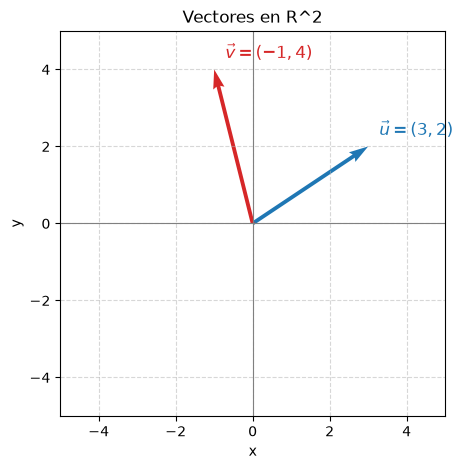

In [3]:
plot_vectores_2d([u2, v2], ['tab:blue', 'tab:red'],
                  [r'$\vec{u}=(3,2)$', r'$\vec{v}=(-1,4)$'])

### Dibujo: vectores en posición estándar en $\mathbb{R}^3$

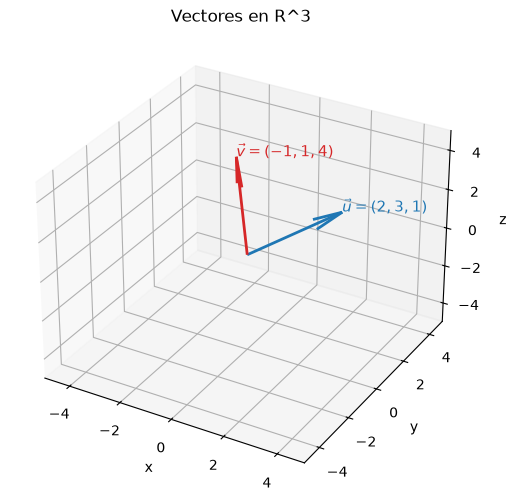

In [4]:
plot_vectores_3d([u3, v3], ['tab:blue', 'tab:red'],
                  [r'$\vec{u}=(2,3,1)$', r'$\vec{v}=(-1,1,4)$'])

## 2. Operaciones básicas con vectores

Trabajaremos con $\vec{u}, \vec{v} \in \mathbb{R}^n$ y un escalar $k \in \mathbb{R}$.

| Operación | Fórmula ($\mathbb{R}^n$) |
|---|---|
| Suma | $\vec{u}+\vec{v} = (u_1+v_1,\ldots,u_n+v_n)$ |
| Resta | $\vec{u}-\vec{v} = (u_1-v_1,\ldots,u_n-v_n)$ |
| Multiplicación por escalar | $k\vec{u} = (ku_1,\ldots,ku_n)$ |
| Magnitud (norma) | $\lVert \vec{u} \rVert = \sqrt{u_1^2+\cdots+u_n^2}$ |
| Vector unitario | $\hat{u} = \dfrac{\vec{u}}{\lVert \vec{u} \rVert}$ |
| Producto punto | $\vec{u}\cdot\vec{v} = u_1v_1+\cdots+u_nv_n$ |
| Ángulo entre vectores | $\cos\theta = \dfrac{\vec{u}\cdot\vec{v}}{\lVert\vec{u}\rVert\,\lVert\vec{v}\rVert}$ |
| Producto cruz (solo en $\mathbb{R}^3$) | $\vec{u}\times\vec{v} = (u_2v_3-u_3v_2,\ u_3v_1-u_1v_3,\ u_1v_2-u_2v_1)$ |

Veamos cada una en código, con $\vec{u}=(3,2)$, $\vec{v}=(-1,4)$ en $\mathbb{R}^2$ y $k=2$.

In [5]:
k = 2

suma2 = u2 + v2
resta2 = u2 - v2
escalar2 = k * u2

print("u2 + v2 =", suma2)
print("u2 - v2 =", resta2)
print(f"{k}*u2   =", escalar2)

u2 + v2 = [2 6]
u2 - v2 = [ 4 -2]
2*u2   = [6 4]


### Dibujo: suma de vectores (regla del paralelogramo / punta-cola)

La suma $\vec{u}+\vec{v}$ se puede visualizar trasladando $\vec{v}$ para que su cola coincida con la punta de $\vec{u}$: la flecha resultante va del origen a la punta de $\vec{v}$ trasladado.

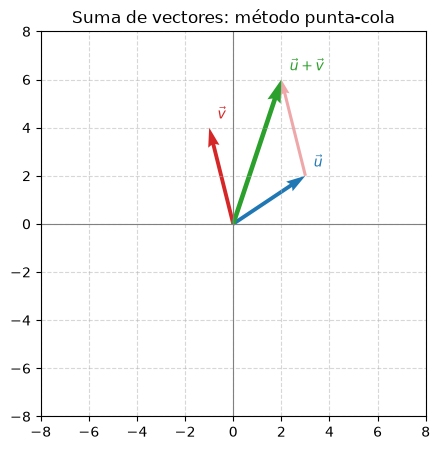

In [6]:
plot_suma_2d(u2, v2)

### Dibujo: resta y multiplicación por escalar

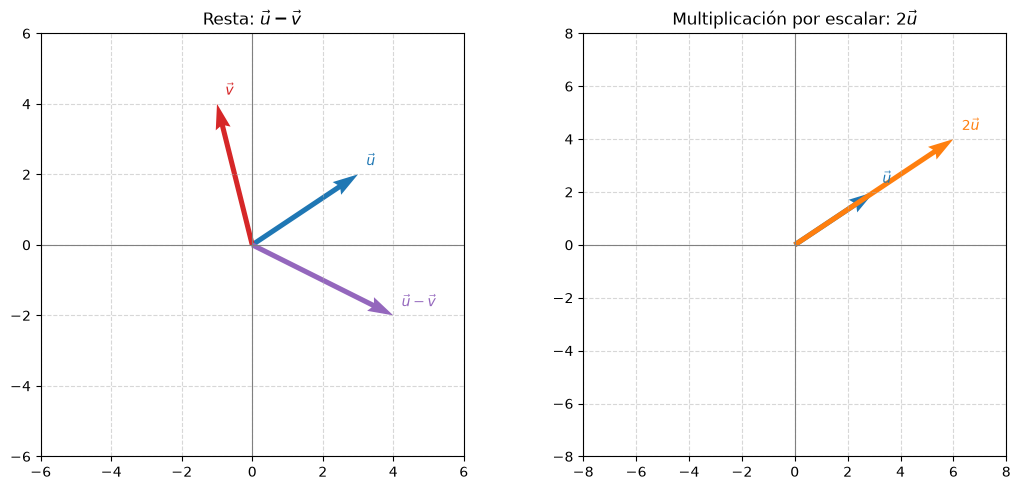

In [7]:
plot_resta_y_escalar_2d(u2, v2, 2)

### Magnitud (norma) y vector unitario

La magnitud de $\vec{u}=(3,2)$ es $\lVert \vec{u} \rVert = \sqrt{3^2+2^2}$, y el vector unitario $\hat{u}$ tiene la misma dirección que $\vec{u}$ pero longitud 1.

In [8]:
norma_u = np.linalg.norm(u2)
u_unitario = u2 / norma_u

print("||u2||   =", norma_u)
print("u2 hat   =", u_unitario)
print("||u_hat||=", np.linalg.norm(u_unitario))

||u2||   = 3.605551275463989
u2 hat   = [0.83205029 0.5547002 ]
||u_hat||= 1.0


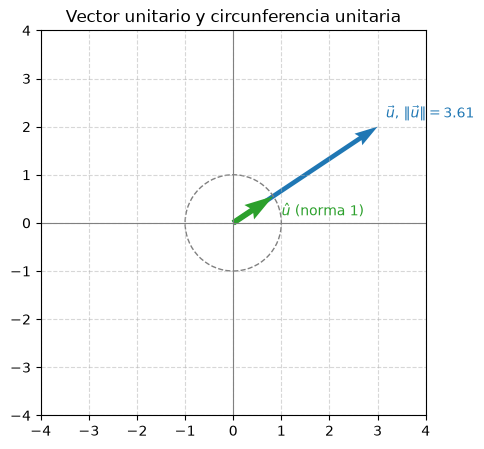

In [9]:
plot_unitario_2d(u2)

### Producto punto y ángulo entre vectores

El producto punto (o escalar) mide qué tanto "apuntan en la misma dirección" dos vectores, y permite calcular el ángulo $\theta$ entre ellos.

In [10]:
punto2 = np.dot(u2, v2)
cos_theta = punto2 / (np.linalg.norm(u2) * np.linalg.norm(v2))
theta = np.degrees(np.arccos(cos_theta))
theta1 = np.arccos(cos_theta)

print("u2 . v2 =", punto2)
print(f"ángulo entre u2 y v2 = {theta:.2f} grados")
print(f"ángulo entre u2 y v2 = {theta1:.2f} radianes")

u2 . v2 = 5
ángulo entre u2 y v2 = 70.35 grados
ángulo entre u2 y v2 = 1.23 radianes


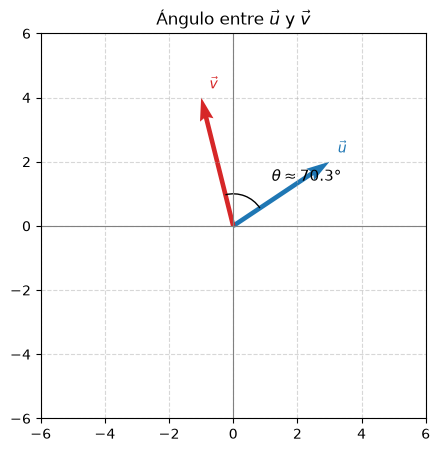

In [11]:
plot_angulo_2d(u2, v2)

## 3. Operaciones en $\mathbb{R}^3$

En $\mathbb{R}^3$ tenemos las mismas operaciones (suma, resta, escalar, norma, unitario, producto punto y ángulo) más una nueva: el **producto cruz**, que produce un vector perpendicular a los dos vectores originales.

In [12]:
suma3 = u3 + v3
resta3 = u3 - v3
escalar3 = k * u3
norma_u3 = np.linalg.norm(u3)
u3_unitario = u3 / norma_u3
punto3 = np.dot(u3, v3)
cruz3 = np.cross(u3, v3)

print("u3 + v3      =", suma3)
print("u3 - v3      =", resta3)
print(f"{k}*u3        =", escalar3)
print("||u3||       =", norma_u3)
print("u3 unitario  =", u3_unitario)
print("u3 . v3      =", punto3)
print("u3 x v3      =", cruz3)
print("(u3 x v3) . u3 =", np.dot(cruz3, u3), "  (⟂ a u3)")
print("(u3 x v3) . v3 =", np.dot(cruz3, v3), "  (⟂ a v3)")

u3 + v3      = [1 4 5]
u3 - v3      = [ 3  2 -3]
2*u3        = [4 6 2]
||u3||       = 3.7416573867739413
u3 unitario  = [0.53452248 0.80178373 0.26726124]
u3 . v3      = 5
u3 x v3      = [11 -9  5]
(u3 x v3) . u3 = 0   (⟂ a u3)
(u3 x v3) . v3 = 0   (⟂ a v3)


## 4. Dependencia lineal y ángulos entre vectores

**Dependencia lineal (geométrica).** Dos vectores $\vec{u}, \vec{v} \in \mathbb{R}^n$ son **linealmente dependientes** si existen escalares $a, b$, no ambos cero, tales que

$$
a\vec{u} + b\vec{v} = \vec{0}
$$

Esto equivale a decir que uno es múltiplo escalar del otro ($\vec{v} = k\vec{u}$), es decir, que son **paralelos** (misma recta que pasa por el origen). Si no existe tal relación, son **linealmente independientes**.

**Criterio práctico en $\mathbb{R}^2$:** $\vec{u}$ y $\vec{v}$ son dependientes si y solo si

$$
\det\begin{pmatrix} u_1 & v_1 \\ u_2 & v_2 \end{pmatrix} = u_1v_2 - u_2v_1 = 0
$$

(el "área" que forman es cero). En $\mathbb{R}^3$, dos vectores son dependientes si $\vec{u}\times\vec{v} = \vec{0}$.

**Ángulo entre vectores.** Ya vimos que $\cos\theta = \dfrac{\vec{u}\cdot\vec{v}}{\lVert\vec{u}\rVert\,\lVert\vec{v}\rVert}$. El ángulo permite clasificar la relación entre dos vectores:

| Condición | Relación |
|---|---|
| $\theta = 0°$ o $180°$ (equiv. $\det=0$ o $\vec{u}\times\vec{v}=\vec{0}$) | **Paralelos** (dependientes) |
| $\theta = 90°$ (equiv. $\vec{u}\cdot\vec{v}=0$) | **Ortogonales** (perpendiculares) |
| $0° < \theta < 90°$ | Forman ángulo agudo |
| $90° < \theta < 180°$ | Forman ángulo obtuso |

In [13]:
# u2, v2 no son paralelos -> independientes
det_uv = u2[0]*v2[1] - u2[1]*v2[0]
print("det(u2, v2) =", det_uv, " -> ", "dependientes" if np.isclose(det_uv, 0) else "independientes")

# Ejemplo de un par paralelo (dependiente): w2 = 2*u2
w2 = 2 * u2
det_uw = u2[0]*w2[1] - u2[1]*w2[0]
print("w2 = 2*u2 =", w2)
print("det(u2, w2) =", det_uw, " -> ", "dependientes" if np.isclose(det_uw, 0) else "independientes")

# Clasificación por ángulo
theta_uv = np.degrees(np.arccos(np.dot(u2, v2) / (np.linalg.norm(u2)*np.linalg.norm(v2))))
print(f"ángulo(u2, v2) = {theta_uv:.2f}°")

det(u2, v2) = 14  ->  independientes
w2 = 2*u2 = [6 4]
det(u2, w2) = 0  ->  dependientes
ángulo(u2, v2) = 70.35°


### Dibujo: vectores independientes vs. dependientes (paralelos)

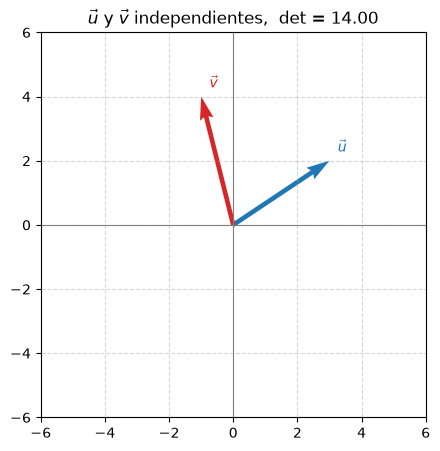

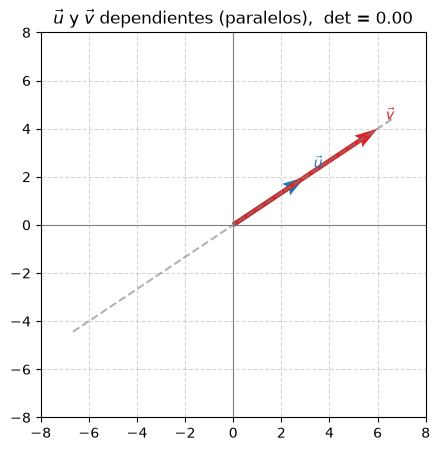

In [14]:
plot_dependencia_2d(u2, v2)   # independientes
plot_dependencia_2d(u2, w2)   # dependientes (paralelos)

## 5. Proyecciones

La **proyección** de $\vec{u}$ sobre $\vec{v}$ (con $\vec{v}\neq\vec{0}$) es el vector que representa la "sombra" de $\vec{u}$ a lo largo de la dirección de $\vec{v}$:

$$
\mathrm{proy}_{\vec{v}}\,\vec{u} = \left(\frac{\vec{u}\cdot\vec{v}}{\lVert\vec{v}\rVert^2}\right)\vec{v} = \left(\frac{\vec{u}\cdot\vec{v}}{\vec{v}\cdot\vec{v}}\right)\vec{v}
$$

También se define la **componente escalar** (o proyección escalar) de $\vec{u}$ sobre $\vec{v}$, que es la longitud con signo de esa sombra:

$$
\mathrm{comp}_{\vec{v}}\,\vec{u} = \frac{\vec{u}\cdot\vec{v}}{\lVert\vec{v}\rVert}
$$

de modo que $\mathrm{proy}_{\vec{v}}\,\vec{u} = \left(\mathrm{comp}_{\vec{v}}\,\vec{u}\right)\hat{v}$, con $\hat{v}=\vec{v}/\lVert\vec{v}\rVert$.

**Componente perpendicular.** Todo vector $\vec{u}$ se puede descomponer como una parte paralela a $\vec{v}$ y una parte ortogonal a $\vec{v}$:

$$
\vec{u} = \underbrace{\mathrm{proy}_{\vec{v}}\,\vec{u}}_{\parallel\, \vec{v}} + \underbrace{\left(\vec{u} - \mathrm{proy}_{\vec{v}}\,\vec{u}\right)}_{\perp\, \vec{v}}
$$

Esta descomposición es la base de aplicaciones como el proceso de Gram-Schmidt y el cálculo de trabajo (física) $W = \vec{F}\cdot\vec{d}$.

In [15]:
comp_v_u = np.dot(u2, v2) / np.linalg.norm(v2)
proy_v_u = (np.dot(u2, v2) / np.dot(v2, v2)) * v2
perp = u2 - proy_v_u

print("comp_v(u2)        =", comp_v_u)
print("proy_v(u2)        =", proy_v_u)
print("componente ⟂      =", perp)
print("proy + perp = u2? ", np.allclose(proy_v_u + perp, u2))
print("proy . perp (≈0)  =", np.dot(proy_v_u, perp))

comp_v(u2)        = 1.212678125181665
proy_v(u2)        = [-0.29411765  1.17647059]
componente ⟂      = [3.29411765 0.82352941]
proy + perp = u2?  True
proy . perp (≈0)  = 1.9208010806663606e-17


### Dibujo: proyección de $\vec{u}$ sobre $\vec{v}$

La línea punteada gris es la recta que contiene a $\vec{v}$; la línea punteada morada muestra la componente perpendicular (el "residuo" entre $\vec{u}$ y su proyección).

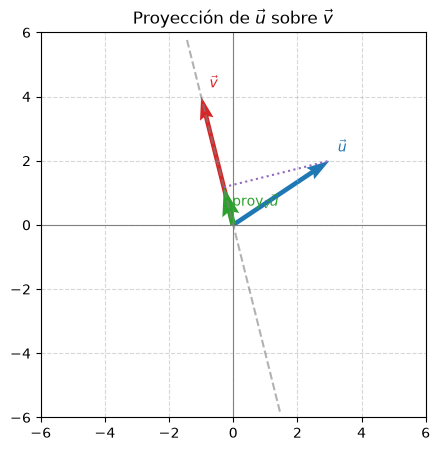

In [16]:
plot_proyeccion_2d(u2, v2)

### Dibujo: suma de vectores en $\mathbb{R}^3$

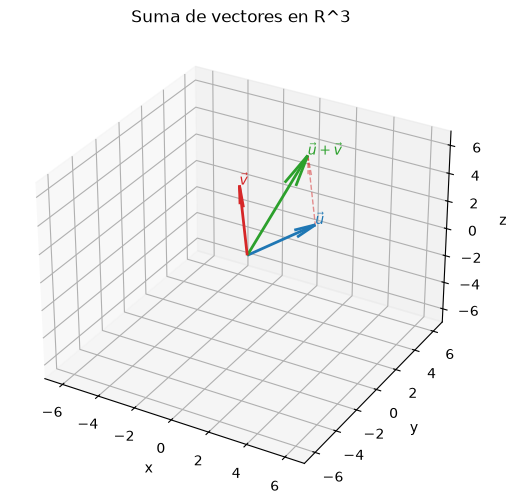

In [17]:
plot_suma_3d(u3, v3)

### Dibujo: producto cruz $\vec{u}\times\vec{v}$

El producto cruz $\vec{u}\times\vec{v}$ es **perpendicular** tanto a $\vec{u}$ como a $\vec{v}$; su magnitud es igual al área del paralelogramo que forman.

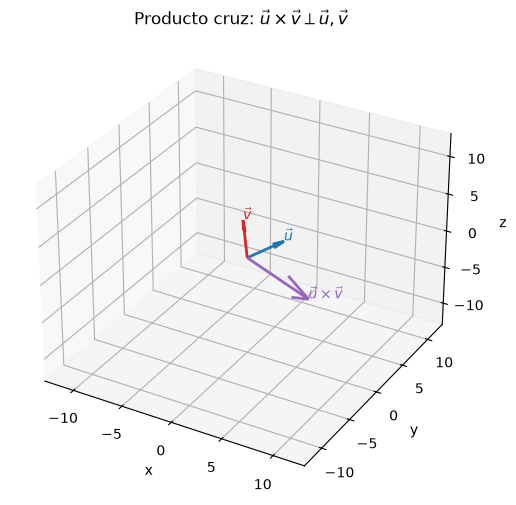

In [18]:
plot_cruz_3d(u3, v3)

## 6. Resumen

- Un vector en $\mathbb{R}^n$ se representa con $n$ componentes: $(x,y)$ en $\mathbb{R}^2$ o $(x,y,z)$ en $\mathbb{R}^3$.
- Geométricamente es una flecha con magnitud, dirección y sentido; en posición estándar parte del origen.
- Las operaciones **suma**, **resta** y **multiplicación por escalar** son componente a componente y tienen interpretación gráfica directa (punta-cola, escalado).
- La **norma** mide la longitud del vector; dividir por la norma da el **vector unitario** (misma dirección, longitud 1).
- El **producto punto** relaciona magnitudes y el ángulo entre vectores; si $\vec{u}\cdot\vec{v}=0$, los vectores son **ortogonales**.
- El **producto cruz** (solo en $\mathbb{R}^3$) produce un vector perpendicular a ambos, con magnitud igual al área del paralelogramo que forman.
- Dos vectores son **linealmente dependientes** si son paralelos ($\det=0$ en $\mathbb{R}^2$, o $\vec{u}\times\vec{v}=\vec{0}$ en $\mathbb{R}^3$); el ángulo entre ellos permite clasificar la relación (paralelos, ortogonales, agudo, obtuso).
- La **proyección** $\mathrm{proy}_{\vec{v}}\vec{u}$ descompone a $\vec{u}$ en una parte paralela y una parte perpendicular a $\vec{v}$.

## 7. Ejercicios

Resuelve a mano y luego verifica tus respuestas con `numpy` en una celda de código.

### A. Suma y resta de vectores

1. $(2,5) + (3,-1)$
2. $(-4,6) + (4,-6)$
3. $(1,2,3) + (0,-2,5)$
4. $(7,-3) - (2,4)$
5. $(3,0,-2) - (-1,5,1)$

### B. Multiplicación por escalar

6. $4 \cdot (2,-3)$
7. $-2 \cdot (1,1,1)$
8. $\tfrac{1}{2} \cdot (6,-8)$
9. $3 \cdot (0,4,-1) + 2 \cdot (1,-1,2)$
10. Si $\vec{u}=(2,-1)$, encuentra $-3\vec{u}$ y compara su dirección con la de $\vec{u}$.

### C. Descubrir incógnitas en sumas y multiplicaciones por escalar

11. $(x, 3) + (2, -5) = (7, -2)$. Encuentra $x$.
12. $(4, y) + (-1, 6) = (3, 2)$. Encuentra $y$.
13. $k \cdot (2, 5) = (8, 20)$. Encuentra el escalar $k$.
14. $k \cdot (-3, 6, 9) = (-1, 2, 3)$. Encuentra $k$.
15. $(x, y) + (3, -2) = (0, 0)$. Encuentra $x$ e $y$.
16. $2 \cdot (x, 4) - (1, y) = (5, 3)$. Encuentra $x$ e $y$.
17. Si $\vec{u} = (a, 2, -1)$ y $2\vec{u} = (6, b, c)$, encuentra $a$, $b$ y $c$.

**Sugerencia:** para verificar, define los vectores conocidos con `np.array` y despeja la incógnita algebraicamente antes de comprobar el resultado en código.

### D. Dependencia lineal y ángulos

18. Determina si $(4,6)$ y $(6,9)$ son linealmente dependientes usando el determinante.
19. Determina si $(1,2)$ y $(3,-1)$ son dependientes o independientes.
20. Encuentra el valor de $k$ para que $(2,5)$ y $(k,10)$ sean dependientes.
21. Calcula el ángulo entre $(1,0)$ y $(0,1)$. ¿Qué relación tienen?
22. Calcula el ángulo entre $(3,4)$ y $(-4,3)$. ¿Qué relación tienen?
23. Verifica que $(1,2,3)$ y $(2,4,6)$ son dependientes usando el producto cruz.
24. ¿Para qué valor de $y$ son $(2,3)$ y $(4,y)$ paralelos?

### E. Proyecciones

25. Calcula $\mathrm{proy}_{\vec{v}}\vec{u}$ para $\vec{u}=(3,4)$ y $\vec{v}=(1,0)$. Interpreta el resultado.
26. Calcula la componente escalar $\mathrm{comp}_{\vec{v}}\vec{u}$ para $\vec{u}=(2,2)$ y $\vec{v}=(1,1)$.
27. Dados $\vec{u}=(5,0)$ y $\vec{v}=(0,3)$, calcula $\mathrm{proy}_{\vec{v}}\vec{u}$. ¿Por qué el resultado tiene sentido geométricamente?
28. Descompón $\vec{u}=(4,2)$ en su componente paralela y perpendicular respecto a $\vec{v}=(1,1)$, y verifica que ambas partes suman $\vec{u}$.
29. En $\mathbb{R}^3$, calcula $\mathrm{proy}_{\vec{v}}\vec{u}$ para $\vec{u}=(1,2,2)$ y $\vec{v}=(0,0,1)$.
30. Si $\mathrm{proy}_{\vec{v}}\vec{u} = \vec{0}$, ¿qué relación deben tener $\vec{u}$ y $\vec{v}$?

**Sugerencia:** para D y E, define los vectores con `np.array` y usa `np.dot`, `np.cross` y `np.linalg.norm` para verificar tus cálculos a mano.

In [19]:
# Espacio para verificar tus respuestas con numpy
# Ejemplo (ejercicio 1):
# print(np.array([2, 5]) + np.array([3, -1]))
